# Envelope Detection & Hilbert Transform Utilities

## Theory

**Envelope detection** is a key step in sonar and DSP for extracting the amplitude (modulation) of a signal, especially for pulsed/AM signals, echo analysis, and energy arrival.

- **Absolute value / rectification:** Quick and simple, but not phase-accurate.
- **Hilbert transform:** Standard for analytic signal construction. Provides precise, phase-correct envelope even for noisy or complex signals.

### Hilbert Transform (Analytic Signal)

Given a real-valued signal $x(t)$, the analytic signal is:
$$
x_a(t) = x(t) + j \cdot \hat{x}(t)
$$
where $\hat{x}(t)$ is the Hilbert transform of $x(t)$.

The **envelope** is:
$$
\text{Envelope}(t) = |x_a(t)| = \sqrt{ x(t)^2 + \hat{x}(t)^2 }
$$

**In sonar:** Used for echo strength, pulse arrival time, modulation analysis, and for visualization of noisy returns.

---


In [1]:
import numpy as np
from scipy.signal import hilbert
import matplotlib.pyplot as plt

def compute_envelope_hilbert(signal):
    """Return analytic-signal envelope via Hilbert transform."""
    analytic_signal = hilbert(signal)
    return np.abs(analytic_signal)

def compute_envelope_abs(signal):
    """Return rectified (absolute value) envelope."""
    return np.abs(signal)


### Envelope Detection Demo (Noisy Pulse)

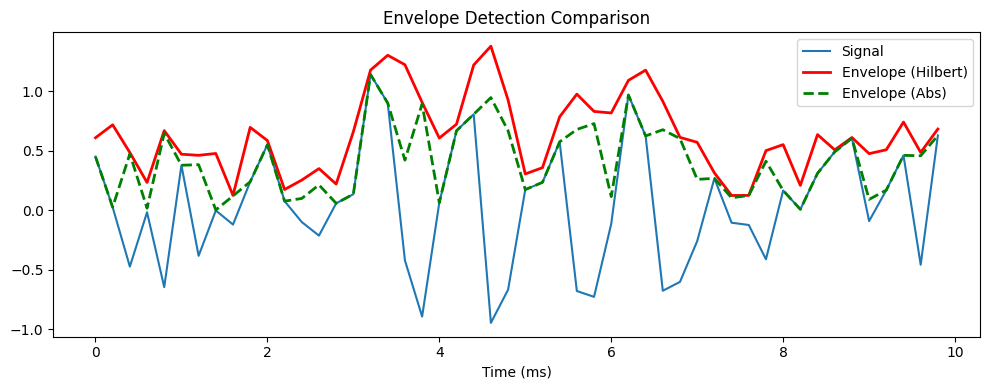

In [2]:
fs = 5000
t = np.linspace(0, 0.01, int(0.01*fs), endpoint=False)
pulse = np.sin(2*np.pi*1000*t) * (t > 0.003) * (t < 0.007)
signal = pulse + 0.3*np.random.randn(len(t))

env_hilb = compute_envelope_hilbert(signal)
env_abs = compute_envelope_abs(signal)

plt.figure(figsize=(10,4))
plt.plot(t*1e3, signal, label='Signal')
plt.plot(t*1e3, env_hilb, 'r', lw=2, label='Envelope (Hilbert)')
plt.plot(t*1e3, env_abs, 'g--', lw=2, label='Envelope (Abs)')
plt.title('Envelope Detection Comparison')
plt.xlabel('Time (ms)')
plt.legend()
plt.tight_layout()
plt.show()


---
## Usage Tips

- Use **Hilbert envelope** for accurate amplitude/energy analysis, even in noisy, multi-component signals.
- Use **abs()** for quick, rough envelope (e.g., for rectified AM signals).
- Envelope detection is essential for time-of-arrival, SNR, and transient/echo analysis in sonar and general DSP.

**Add this tool to your pipeline for robust amplitude-based analysis!**
